In [226]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [227]:
df = pd.read_csv('data/hospital_readmissions.csv')
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [228]:
df['glucose_test'].value_counts()

glucose_test
no        23625
normal      689
high        686
Name: count, dtype: int64

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [230]:
df.dtypes

age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

In [231]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

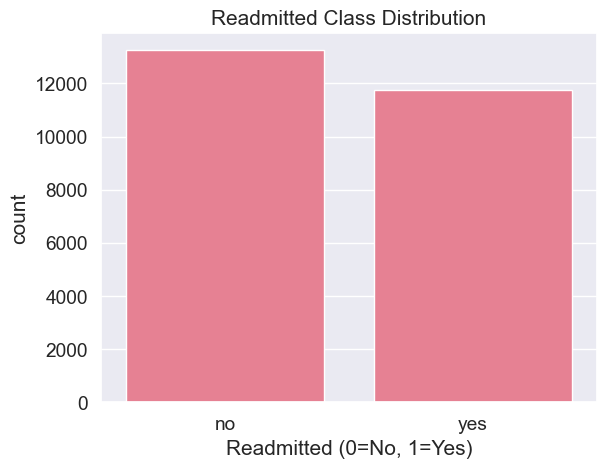

In [232]:

sns.countplot(x='readmitted', data=df)
plt.title('Readmitted Class Distribution')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('count')
plt.show()

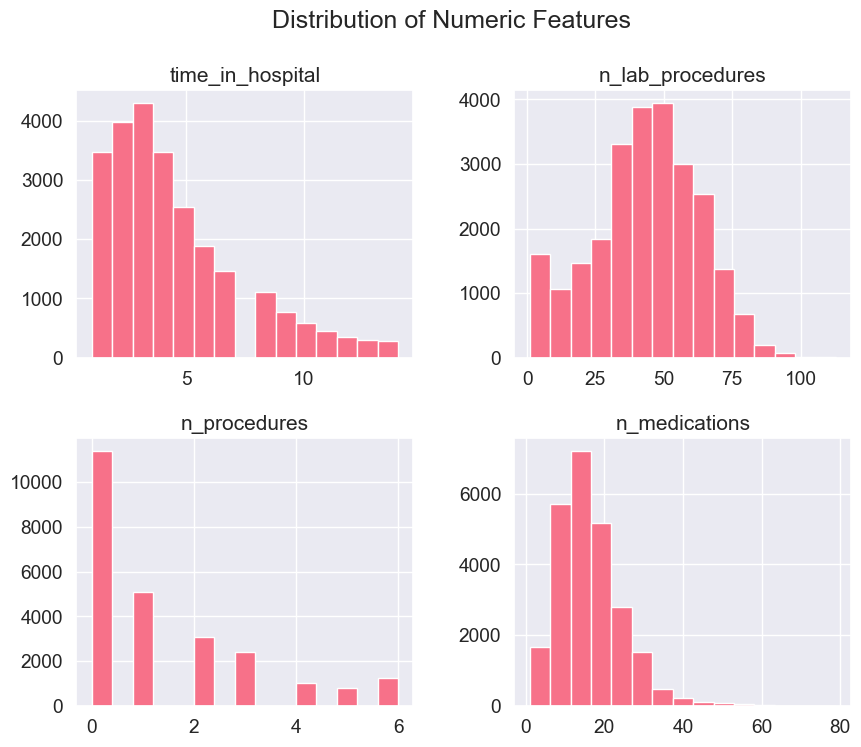

In [233]:
# Histograms for numeric features
numeric_features = ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications']
df[numeric_features].hist(figsize=(10,8), bins=15)
plt.figsize=(12,10)

plt.suptitle('Distribution of Numeric Features')
plt.show()

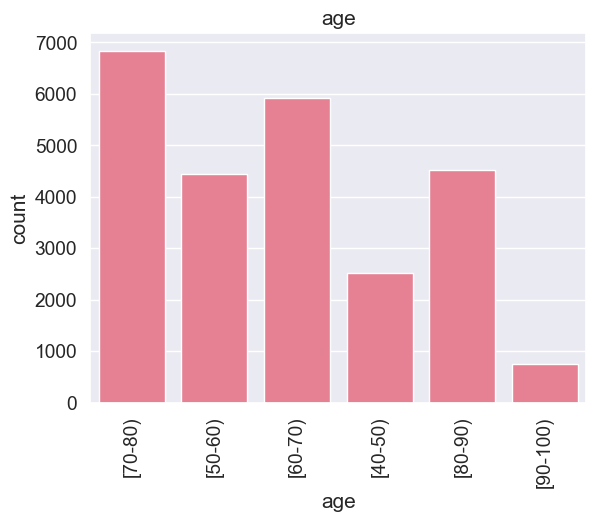

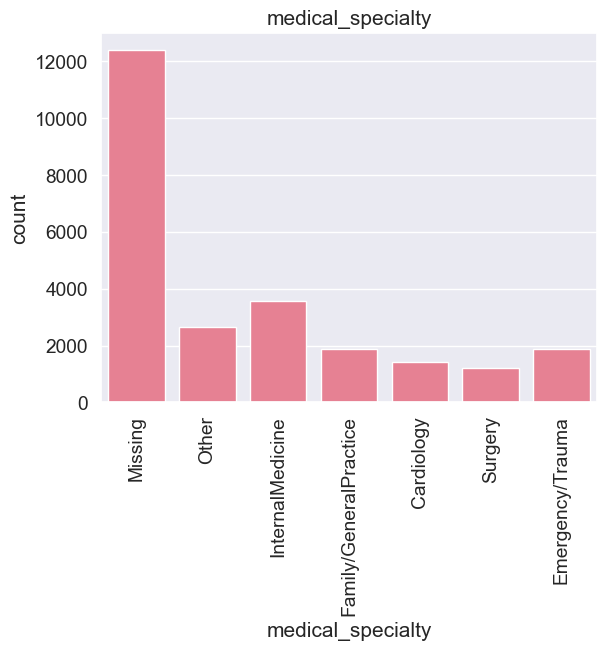

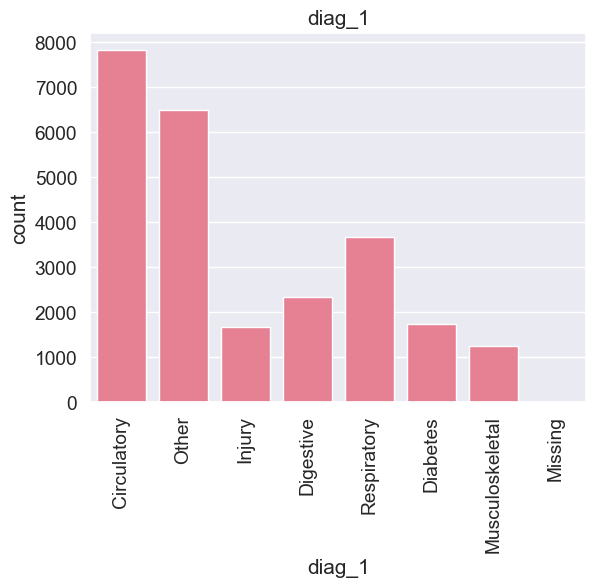

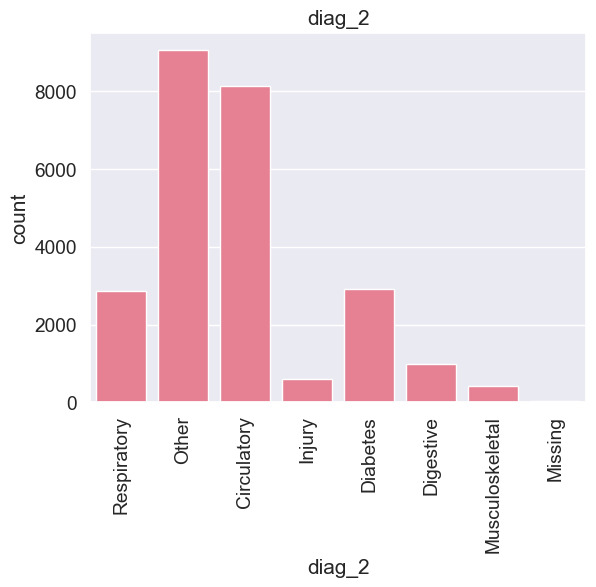

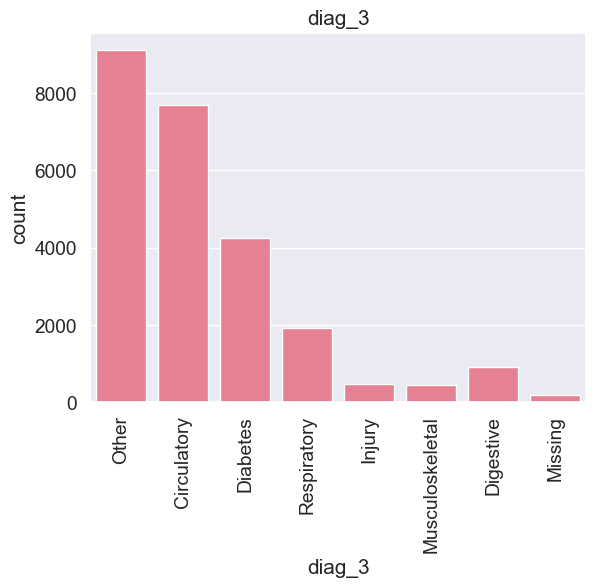

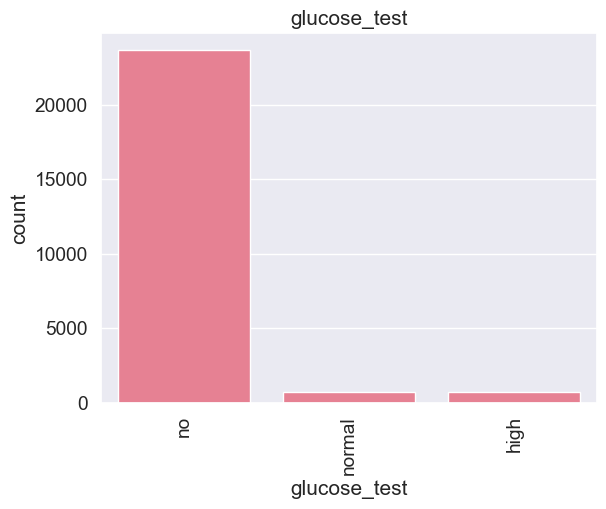

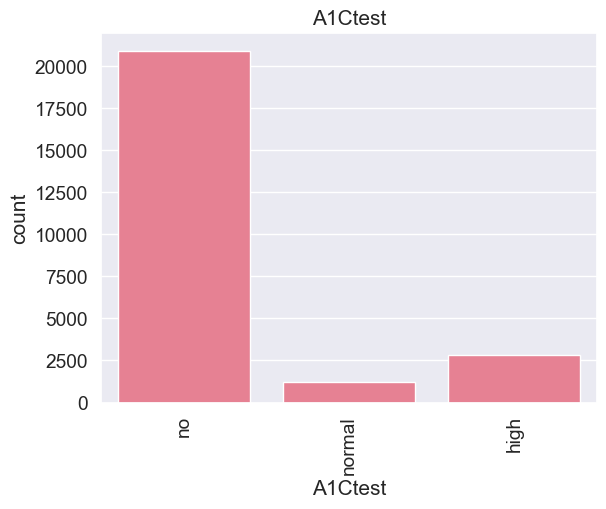

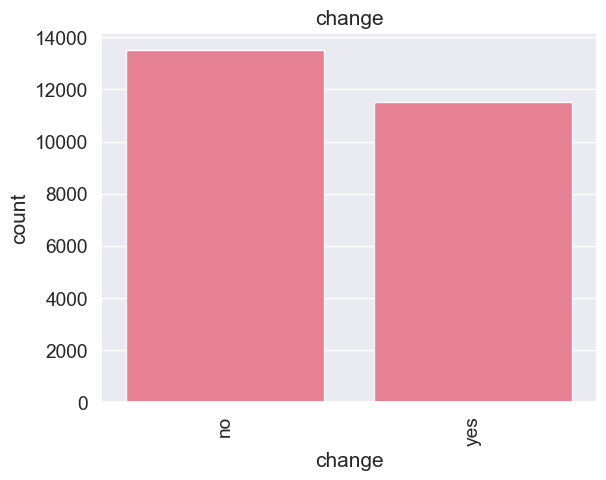

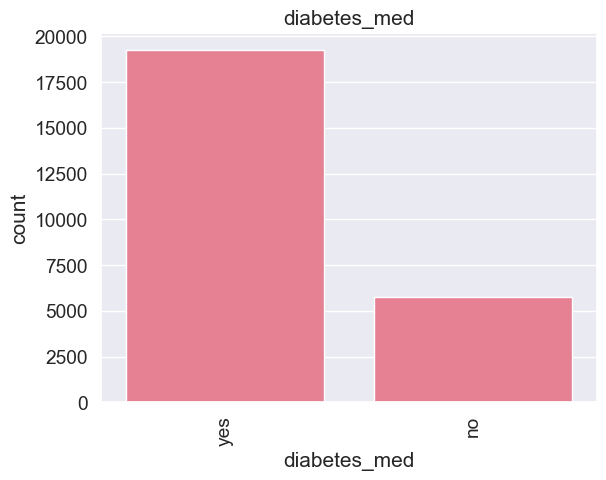

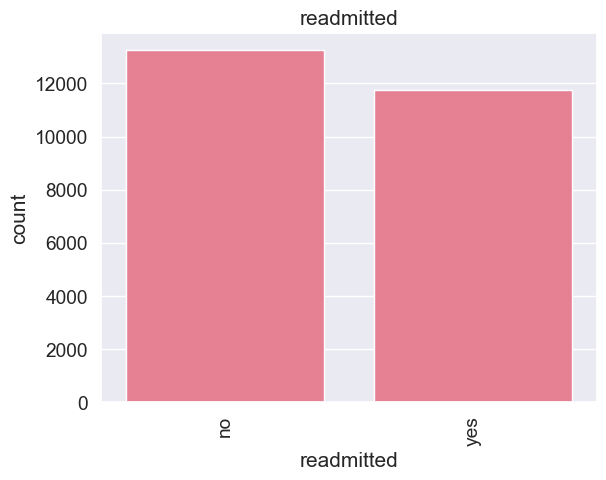

In [234]:


columns = ['age','medical_specialty','diag_1','diag_2','diag_3','glucose_test','A1Ctest','change','diabetes_med','readmitted']

sns.set(style='darkgrid',font_scale=1.25)
sns.set_palette('husl',3)

def plot_cat_count():
    for c in columns:
        sns.countplot(x=c, data=df)
        plt.title(c)
        plt.xticks(rotation=90)
        plt.show()
        
plot_cat_count()

In [235]:
from sklearn.utils import resample

# -------- Balance glucose_test --------
df_no = df[df['glucose_test'] == 'no']
df_normal = df[df['glucose_test'] == 'normal']
df_high = df[df['glucose_test'] == 'high']

# Limit oversampling to 70% of 'no' count
target_size = int(len(df_no) * 0.7)

df_normal_up = resample(df_normal, replace=True, n_samples=target_size, random_state=42)
df_high_up   = resample(df_high,   replace=True, n_samples=target_size, random_state=42)

df = pd.concat([df_no, df_normal_up, df_high_up])

In [240]:
# -------- Balance A1Ctest --------
df_no = df[df['A1Ctest'] == 'no']
df_gt7 = df[df['A1Ctest'] == 'normal']
df_gt8 = df[df['A1Ctest'] == 'high']

# Limit oversampling to 50% of 'no' count
target_size = int(len(df_no) * 0.5)

df_gt7_up = resample(df_gt7, replace=True, n_samples=target_size, random_state=42)
df_gt8_up = resample(df_gt8, replace=True, n_samples=target_size, random_state=42)

df = pd.concat([df_no, df_gt7_up, df_gt8_up]).reset_index(drop=True)

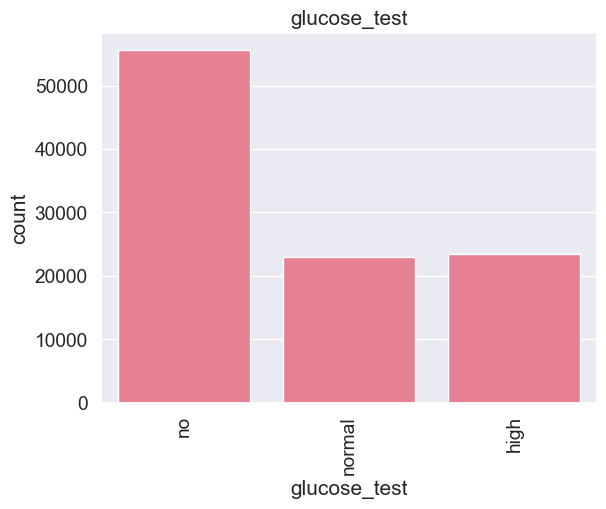

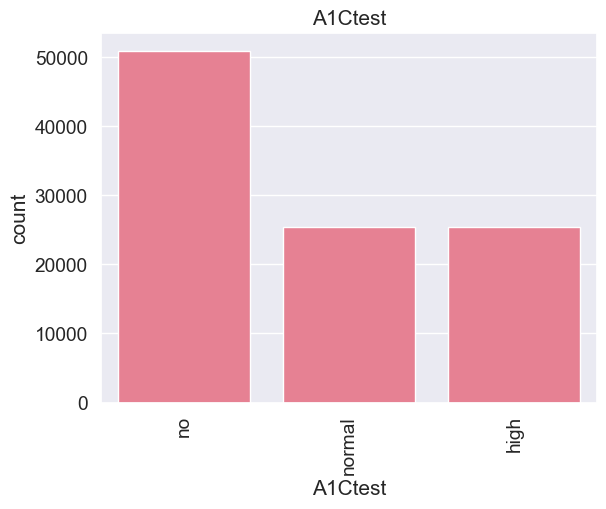

In [241]:

columns = ['glucose_test','A1Ctest']

sns.set(style='darkgrid',font_scale=1.25)
sns.set_palette('husl',3)

def plot_cat_count():
    for c in columns:
        sns.countplot(x=c, data=df)
        plt.title(c)
        plt.xticks(rotation=90)
        plt.show()
        
plot_cat_count()

In [242]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_pie(df, column):
    cat_counts = df[column].value_counts()
    plt.figure(figsize=(8, 8))

    # Generate as many distinct colors as categories
    colors = cm.tab20(np.linspace(0, 1, len(cat_counts)))

    wedges, texts, autotexts = plt.pie(
        cat_counts,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.8,
        colors=colors
    )

    for a in autotexts:
        a.set_fontsize(10)

    plt.legend(
        wedges,
        cat_counts.index,
        title=f"{column} categories",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(f"{column} Distribution")
    plt.tight_layout()
    plt.show()




In [243]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['age', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']
label_encoders = {col: LabelEncoder() for col in categorical_cols}

for col,le in label_encoders.items():
  df[col] = le.fit_transform(df[col].astype(str))

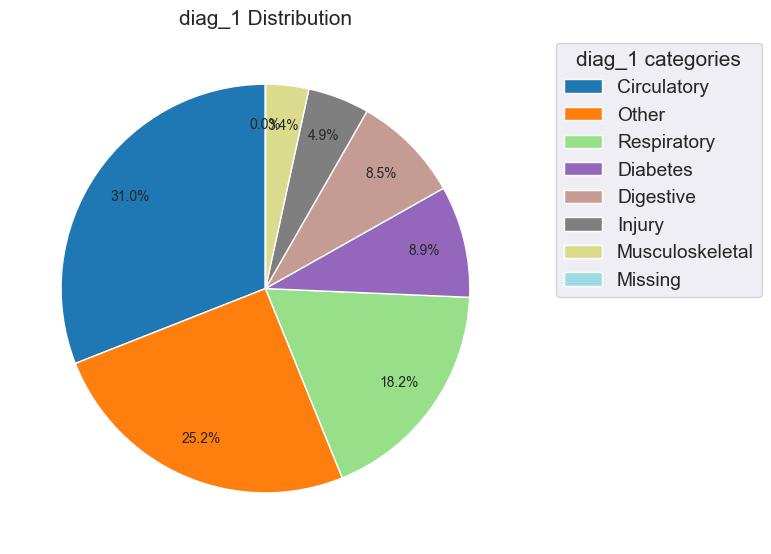

In [244]:
plot_pie(df, 'diag_1')

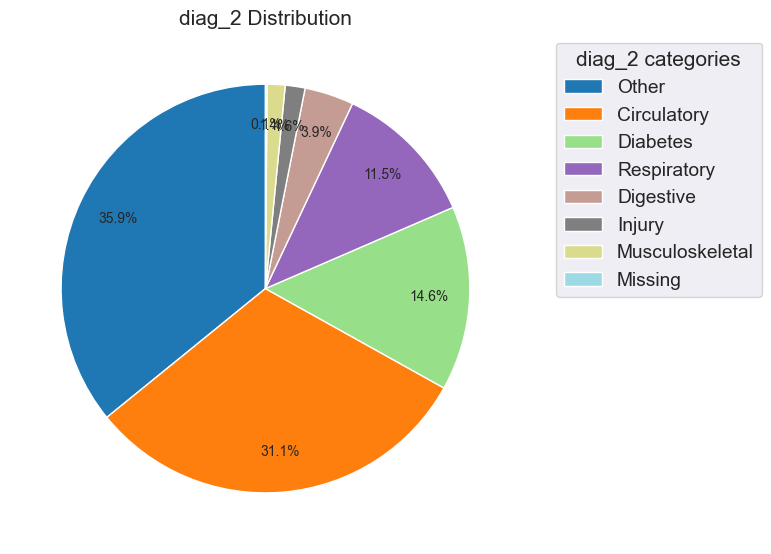

In [245]:
plot_pie(df, 'diag_2')

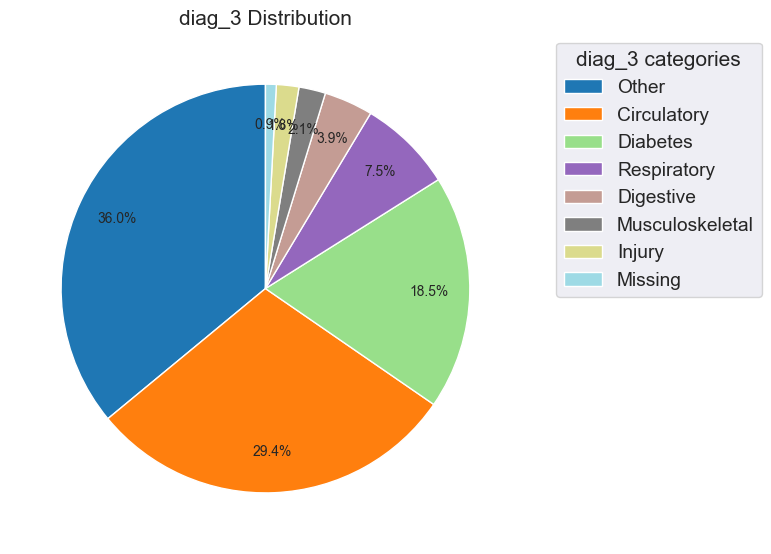

In [246]:
plot_pie(df, 'diag_3')

In [247]:
df.head(10)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3,8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,1,1,0,1,0
1,3,3,34,2,13,0,0,0,Other,Other,Other,Other,1,1,0,1,0
2,1,5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,1,1,1,1,1
3,3,2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,1,1,1,1,1
4,2,1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,1,1,0,1,0
5,0,2,51,0,10,0,0,0,Missing,Other,Other,Other,1,1,0,0,1
6,2,1,19,6,16,0,0,1,Other,Circulatory,Other,Other,1,1,0,1,1
7,4,4,67,3,13,0,0,0,InternalMedicine,Digestive,Other,Other,1,1,0,0,1
8,3,8,37,1,18,0,0,0,Family/GeneralPractice,Respiratory,Respiratory,Other,1,1,1,1,0
9,3,1,35,0,7,0,0,0,Missing,Injury,Injury,Injury,1,1,1,1,0


In [248]:
threshold = 0.02  

# Calculate frequency of each category
freq = df["medical_specialty"].value_counts(normalize=True)

# Categories to keep
common_cats = freq[freq >= threshold].index

# Replace rare categories with "Other"
df["medical_specialty"] = df["medical_specialty"].apply(lambda x: x if x in common_cats else "Other")

In [249]:
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3,8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,1,1,0,1,0
1,3,3,34,2,13,0,0,0,Other,Other,Other,Other,1,1,0,1,0
2,1,5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,1,1,1,1,1
3,3,2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,1,1,1,1,1
4,2,1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101956,0,3,66,0,11,0,0,0,Other,Diabetes,Other,Diabetes,1,0,0,1,0
101957,3,10,53,0,15,0,0,0,Other,Diabetes,Respiratory,Other,1,0,1,1,0
101958,0,8,57,3,19,0,0,0,InternalMedicine,Circulatory,Diabetes,Respiratory,0,0,1,1,1
101959,0,5,59,0,9,0,0,0,InternalMedicine,Respiratory,Diabetes,Other,1,0,0,1,0


In [250]:
df["total_visits"] = df["n_outpatient"] + df["n_inpatient"] + df["n_emergency"]

df["high_risk"] = np.where((df["A1Ctest"] == "High") | (df["glucose_test"] == "High"), 1, 0)

In [251]:
def severity(days):
    if days <= 3:
        return "low"
    elif days <= 7:
        return "medium"
    else:
        return "high"

df["severity"] = df["time_in_hospital"].apply(severity)

In [252]:
df['severity'] = df['severity'].replace({'low':0,'medium':1,'high':2})
                                          

C:\Users\Kannadasan\AppData\Local\Temp\ipykernel_15588\379654066.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['severity'] = df['severity'].replace({'low':0,'medium':1,'high':2})


In [253]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']


categories = pd.unique(df[diag_cols].values.ravel())

one_hot = pd.DataFrame(0, index=df.index, columns=categories)

for col in diag_cols:
    one_hot = one_hot | pd.get_dummies(df[col]).reindex(columns=categories, fill_value=0)

one_hot = one_hot.astype(int)

df_dropped = df.drop(columns=diag_cols)

insert_at = 9

left = df_dropped.iloc[:, :insert_at]
right = df_dropped.iloc[:, insert_at:]


df_final = pd.concat([left, one_hot, right], axis=1)


print(df_final.head())

   age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0    3                 8                72             1             18   
1    3                 3                34             2             13   
2    1                 5                45             0             18   
3    3                 2                36             0             12   
4    2                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty  Circulatory  ...  \
0             2            0            0           Missing            1  ...   
1             0            0            0             Other            0  ...   
2             0            0            0           Missing            1  ...   
3             1            0            0           Missing            1  ...   
4             0            0            0  InternalMedicine            1  ...   

   Musculoskeletal  Missing  glucose_test  A1Ctest  change  di

In [254]:
df=df_final

In [255]:
categorical_cols_2 = ['medical_specialty']
label_encoders_2 = {col: LabelEncoder() for col in categorical_cols_2}

for col2,le in label_encoders_2.items():
  df[col2] = le.fit_transform(df[col2].astype(str))

In [256]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,Circulatory,...,Musculoskeletal,Missing,glucose_test,A1Ctest,change,diabetes_med,readmitted,total_visits,high_risk,severity
0,3,8,72,1,18,2,0,0,4,1,...,0,0,1,1,0,1,0,2,0,2
1,3,3,34,2,13,0,0,0,5,0,...,0,0,1,1,0,1,0,0,0,0
2,1,5,45,0,18,0,0,0,4,1,...,0,0,1,1,1,1,1,0,0,1
3,3,2,36,0,12,1,0,0,4,1,...,0,0,1,1,1,1,1,1,0,0
4,2,1,42,0,7,0,0,0,3,1,...,0,0,1,1,0,1,0,0,0,0


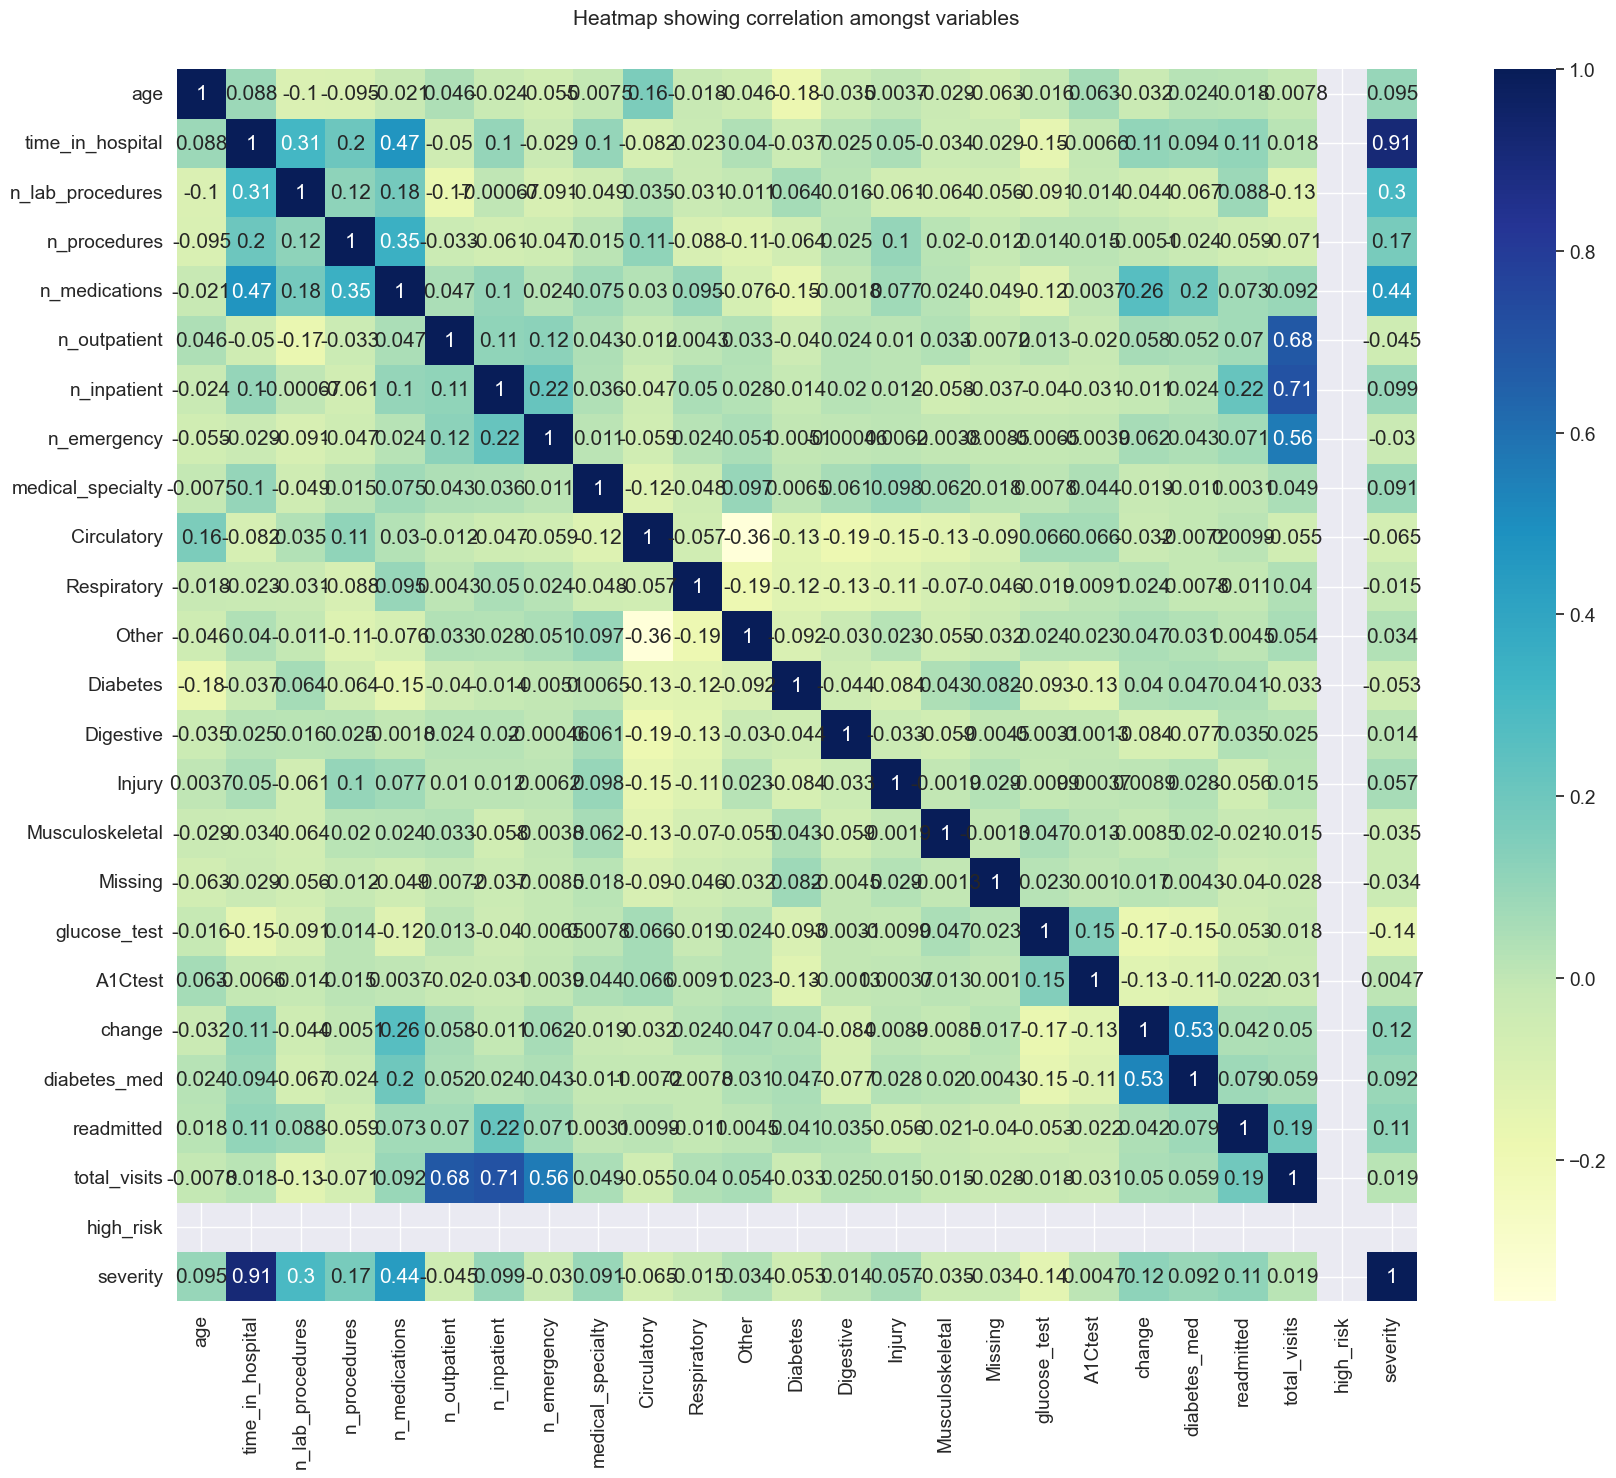

In [257]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), cmap='YlGnBu', fmt='.2g', annot=True)

plt.title('Heatmap showing correlation amongst variables',y=1.03)
plt.show()

In [258]:
X = df.drop(columns=["readmitted"])   # all other columns as features
y = df["readmitted"]

print('X shape:', X.shape)
#print('X_features:',X_features.shape)
print('y shape:', y.shape)

X shape: (101961, 24)
y shape: (101961,)


In [259]:
df['readmitted'].value_counts()

readmitted
0    51527
1    50434
Name: count, dtype: int64

In [260]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,Circulatory,...,Musculoskeletal,Missing,glucose_test,A1Ctest,change,diabetes_med,readmitted,total_visits,high_risk,severity
0,3,8,72,1,18,2,0,0,4,1,...,0,0,1,1,0,1,0,2,0,2
1,3,3,34,2,13,0,0,0,5,0,...,0,0,1,1,0,1,0,0,0,0
2,1,5,45,0,18,0,0,0,4,1,...,0,0,1,1,1,1,1,0,0,1
3,3,2,36,0,12,1,0,0,4,1,...,0,0,1,1,1,1,1,1,0,0
4,2,1,42,0,7,0,0,0,3,1,...,0,0,1,1,0,1,0,0,0,0


In [261]:
df.drop(['n_outpatient', 'n_inpatient', 'n_emergency', 'time_in_hospital', 'A1Ctest'], 
        axis=1, inplace=True)


In [262]:
### Splitting the Data

from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [263]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [264]:
### Baseline Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, pair_confusion_matrix


log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.65      0.63     10274
           1       0.62      0.57      0.60     10119

    accuracy                           0.61     20393
   macro avg       0.61      0.61      0.61     20393
weighted avg       0.61      0.61      0.61     20393

ROC-AUC: 0.613474512172194


c:\Users\Kannadasan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [265]:
### Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92     10274
           1       0.93      0.91      0.92     10119

    accuracy                           0.92     20393
   macro avg       0.92      0.92      0.92     20393
weighted avg       0.92      0.92      0.92     20393

ROC-AUC Score: 0.9193729474230379


In [266]:
# Adjusting Hyperparameters for the Random Forest Classifier

rf_tuned = RandomForestClassifier(
    bootstrap=True,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)

#Training the model
rf_tuned.fit(X_train, y_train)


#Predicting on the test set
y_pred_tuned = rf_tuned.predict(X_test)
y_proba_tuned = rf_tuned.predict_proba(X_test)[:,1]

#Evaluate Performance
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_tuned))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82     10274
           1       0.84      0.75      0.79     10119

    accuracy                           0.80     20393
   macro avg       0.81      0.80      0.80     20393
weighted avg       0.81      0.80      0.80     20393

ROC-AUC Score: 0.8033745710452853


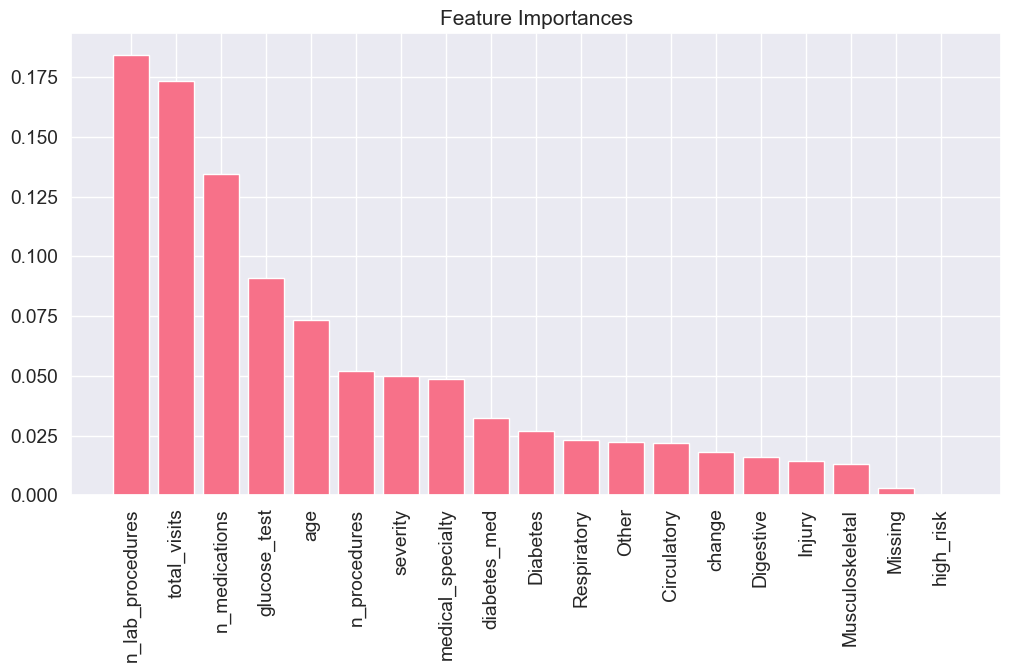

In [267]:
### Feature Importance

importances = rf_tuned.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.show()

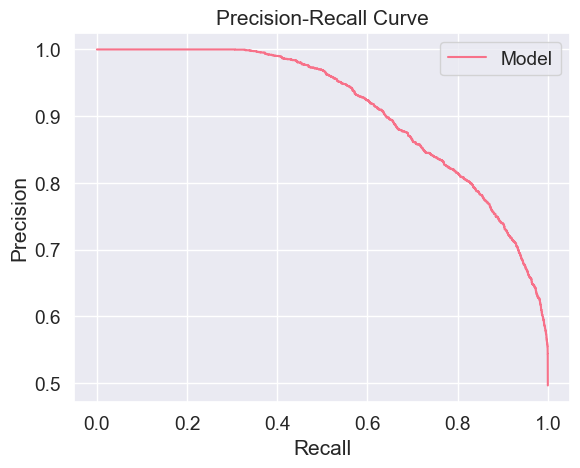

In [268]:
## Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, rf_tuned.predict_proba(X_test)[:,1])
plt.plot(recall, precision, label='Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [269]:
### XGBoost Implementation

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

#Evaluation
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91     10274
           1       0.92      0.91      0.91     10119

    accuracy                           0.91     20393
   macro avg       0.91      0.91      0.91     20393
weighted avg       0.91      0.91      0.91     20393

XGBoost ROC-AUC Score: 0.9778138978162975


In [270]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

#Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

#Evaluation
print("LigthGBM Classification Report:\n", classification_report(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC Score:", roc_auc_score(y_test, y_proba_lgbm))

[LightGBM] [Info] Number of positive: 40315, number of negative: 41253
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 81568, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494250 -> initscore=-0.023000
[LightGBM] [Info] Start training from score -0.023000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LigthGBM Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84     10274
           1       0.86      0.78      0.82     10119

    accuracy                           0.83     20393
   macro avg       0.83      0.83      0.8

In [271]:
results = {
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "ROC-AUC Score": [roc_auc_score(y_test, rf_tuned.predict_proba(X_test)[:, 1]),
                roc_auc_score(y_test, y_proba_xgb),
                roc_auc_score(y_test, y_proba_lgbm)]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  ROC-AUC Score
0  Random Forest       0.902666
1        XGBoost       0.977814
2       LightGBM       0.920545


In [272]:
import tensorflow as tf
# Build model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


c:\Users\Kannadasan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6067 - loss: 0.6621 - val_accuracy: 0.6162 - val_loss: 0.6482
Epoch 2/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6373 - loss: 0.6363 - val_accuracy: 0.6514 - val_loss: 0.6256
Epoch 3/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6554 - loss: 0.6164 - val_accuracy: 0.6606 - val_loss: 0.6041
Epoch 4/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6718 - loss: 0.5979 - val_accuracy: 0.6779 - val_loss: 0.5896
Epoch 5/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6920 - loss: 0.5773 - val_accuracy: 0.6956 - val_loss: 0.5701
Epoch 6/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7048 - loss: 0.5607 - val_accuracy: 0.7115 - val_loss: 0.5560
Epoch 7/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7183 - loss: 0.5447 - val_accuracy: 0.7048 - val_loss: 0.5472
Epoch 8/20
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7255 - loss: 0.5311 - 

In [273]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


638/638 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step
Testing Accuracy: 0.77502084048448
Precision: 0.8286393345216875
Recall: 0.6890997134104161


638/638 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best Model Summary:
Model             XGBoost
Accuracy         0.913353
Precision (0)     0.90848
Recall (0)       0.920771
F1-Score (0)     0.914584
Precision (1)    0.918437
Recall (1)       0.905821
F1-Score (1)     0.912085
ROC-AUC          0.977814
Name: 2, dtype: object

Complete Results Table:


,Model,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1),ROC-AUC
0,Logistic Regression,0.613789,0.608428,0.654857,0.630789,0.620139,0.572092,0.595148,0.659690
1,Random Forest,0.803805,0.775156,0.860035,0.815392,0.840116,0.746714,0.790666,0.902666
2,XGBoost,0.913353,0.908480,0.920771,0.914584,0.918437,0.905821,0.912085,0.977814
3,LightGBM,0.831315,0.804058,0.879502,0.840089,0.864773,0.782390,0.821521,0.920545
4,Neural Network,0.775021,0.737352,0.859646,0.793816,0.828639,0.689100,0.752455,0.871346


C:\Users\Kannadasan\AppData\Local\Temp\ipykernel_15588\211687746.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="viridis")


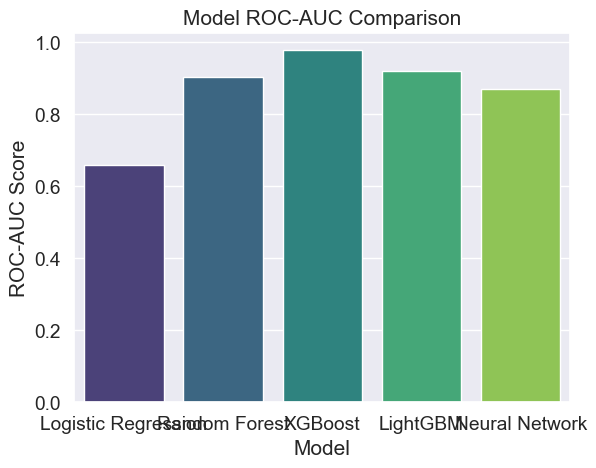

In [274]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import numpy as np

# Define a function to calculate evaluation metrics
def evaluate_model(model, X_test, y_test, model_name, is_nn=False):
    """
    model: trained model
    X_test: test features
    y_test: true labels
    model_name: string
    is_nn: whether the model is a keras NN or not
    """
    if is_nn:  
        # For Neural Network (Keras)
        y_prob = model.predict(X_test).flatten()
        y_pred = (y_prob > 0.5).astype(int)
    else:  
        # For sklearn models
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (0)": metrics["0"]["precision"],
        "Recall (0)": metrics["0"]["recall"],
        "F1-Score (0)": metrics["0"]["f1-score"],
        "Precision (1)": metrics["1"]["precision"],
        "Recall (1)": metrics["1"]["recall"],
        "F1-Score (1)": metrics["1"]["f1-score"],
        "ROC-AUC": roc_auc
    }

# ------------------------
# Evaluate all models
results = []

# Logistic Regression
results.append(evaluate_model(log_reg, X_test, y_test, "Logistic Regression"))

# Random Forest
results.append(evaluate_model(rf_tuned, X_test, y_test, "Random Forest"))

# XGBoost
results.append(evaluate_model(xgb, X_test, y_test, "XGBoost"))

# LightGBM
results.append(evaluate_model(lgbm, X_test, y_test, "LightGBM"))

# Neural Network (Keras example)
results.append(evaluate_model(model, X_test, y_test, "Neural Network", is_nn=True))

# Convert results to a DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# Highlight the best-performing model
best_model = results_df.loc[results_df["ROC-AUC"].idxmax()]
print("Best Model Summary:")
print(best_model)

# Display the full results table
import seaborn as sns
import matplotlib.pyplot as plt

print("\nComplete Results Table:")
display(results_df)

# Plot the metrics for visualization
sns.barplot(data=results_df, x="Model", y="ROC-AUC", palette="viridis")
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.show()
